In [ ]:
import sys
sys.path.append('/data/biophys/schimmenti/Repositories/MHN-Bif/')
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from mhnlib.dynamics import Dynamics, DualDynamics
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
folder = Path("SwitchingTrap/280nm/")
files = list(folder.glob("*.txt"))
file = files[0]
data = np.loadtxt(file)
t = data[:, 0]
x = data[:, [1,2]]
x_mean = np.mean(x, axis=0)
x_std = np.std(x, axis=0)
x = (x - x_mean) / x_std
x = torch.tensor(x, dtype=torch.float32)

In [98]:
num_samples = 10000
samples =  x[torch.randint(0, x.shape[0], (num_samples,))]
#samples -= samples.mean(dim=0)
#samples /= torch.linalg.norm(samples, dim=1).square().mean().sqrt()
num_ics = 100
x_ics = torch.randn(num_ics, 2)
biases = -0.5*samples.pow(2).sum(dim=1)
betas = torch.logspace(0,3,10)
mhn_dynamics = Dynamics(samples.to(device), biases.to(device))

In [99]:
x_conv = mhn_dynamics.discrete_num_iters(x_ics.to(device), betas.to(device), num_iters=1000).cpu()

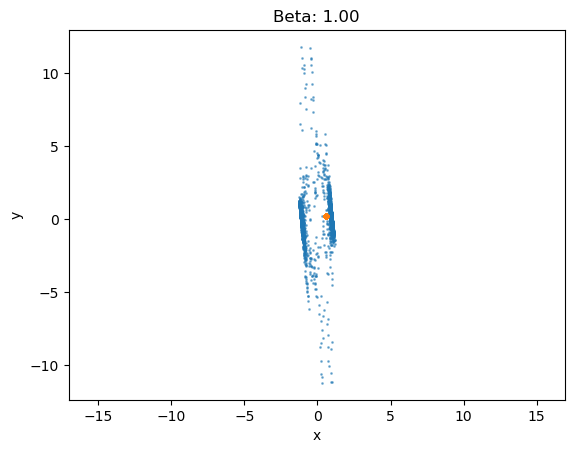

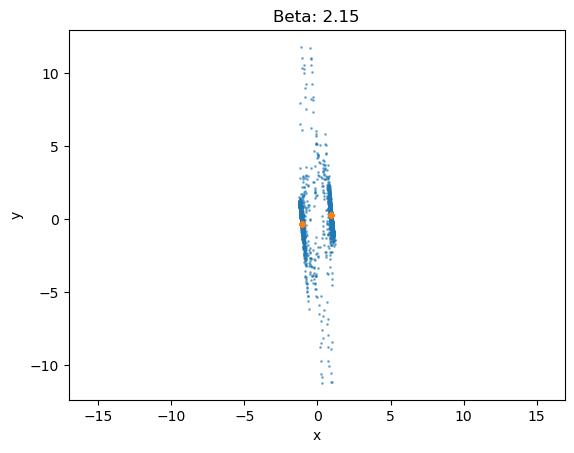

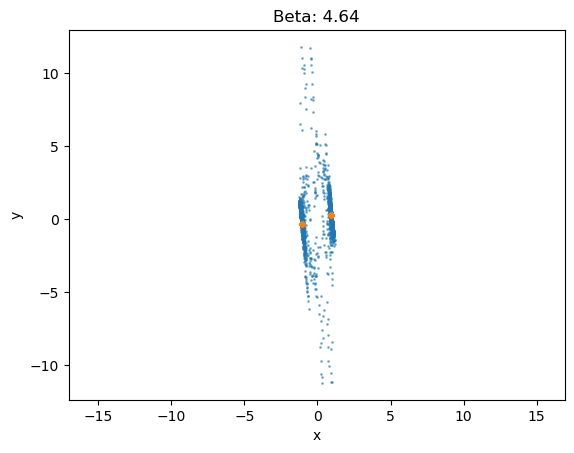

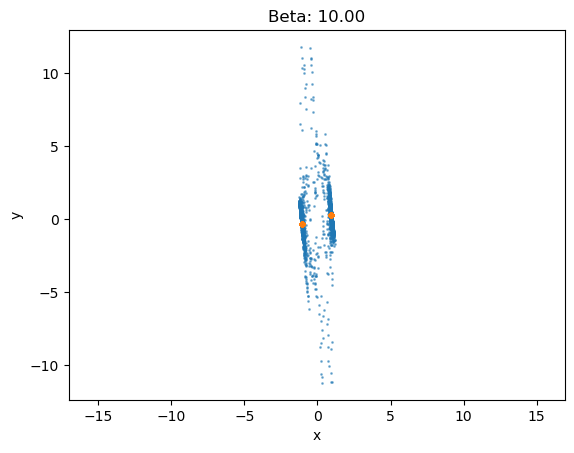

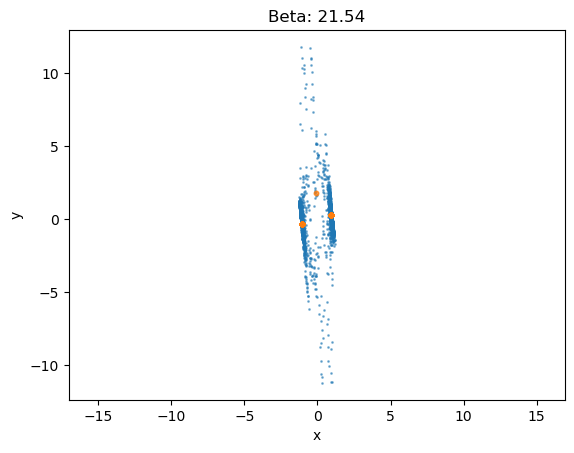

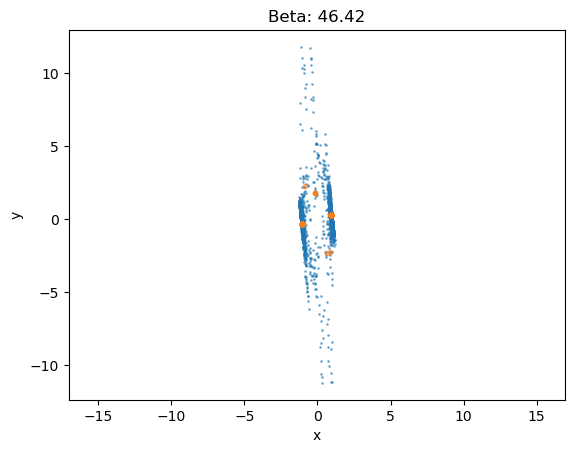

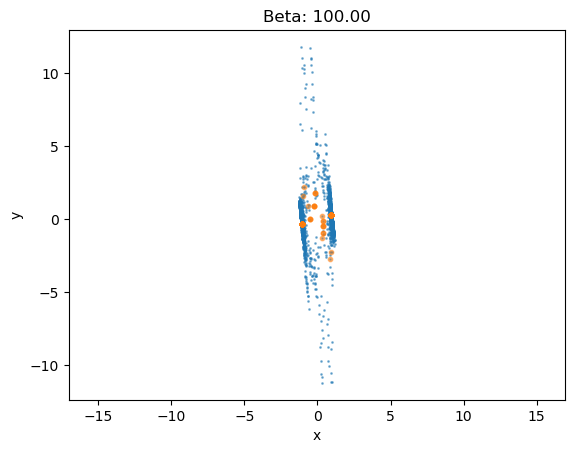

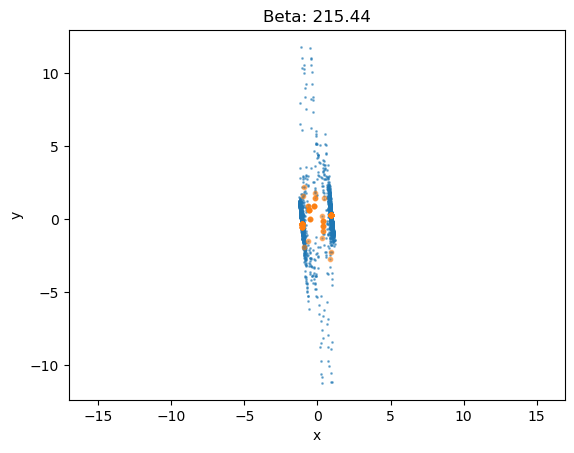

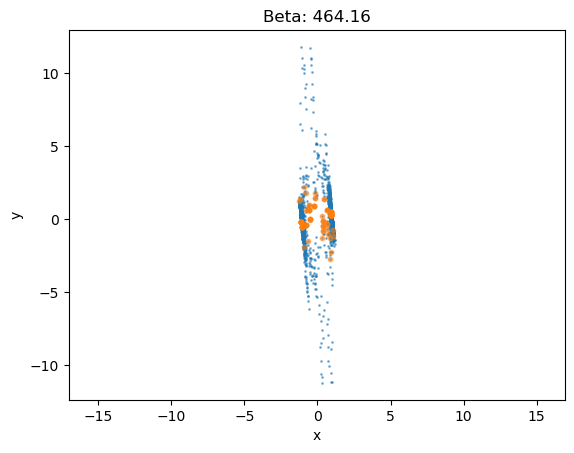

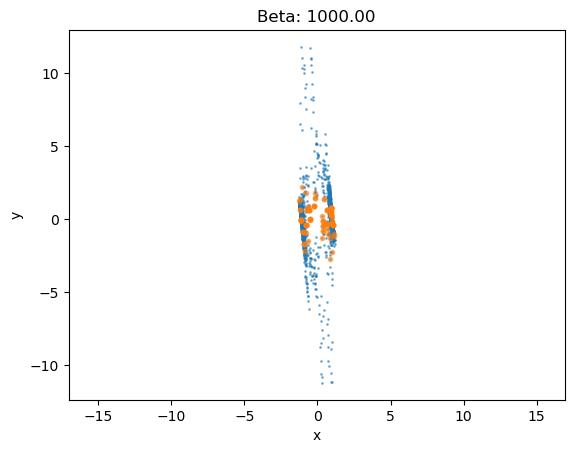

In [100]:
for beta_idx in range(betas.shape[0]):
    plt.figure()
    plt.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.5)
    plt.scatter(x_conv[beta_idx, :, 0], x_conv[beta_idx, :, 1], s=10, alpha=0.5)
    plt.title(f"Beta: {betas[beta_idx].item():.2f}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis('equal')
    plt.show()